# Autodistillation de GroundingDino vers YOLOv8

## Python stuff
> Attention il faut downgrade `transformers==5.XX.XX` vers `transformers==4.XX.XX` pour utiliser `autodistill_grounding_dino`.

In [2]:
import transformers

transformers.__version__

'4.41.2'

In [1]:
from autodistill_grounding_dino import GroundingDINO
from autodistill.detection import CaptionOntology
from autodistill_yolov8 import YOLOv8
import supervision as sv
import cv2
import os
import torch
import random
from autodistill.utils import plot


torch.use_deterministic_algorithms(False)

Importing from timm.models.layers is deprecated, please import via timm.layers
pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


# Configuration du base model
> Base model GoundingDino paramètres : plant, animal

In [5]:
# TODO: Partie perfectible cf. travaux de ceux qui se sont focalisés sur le prompt
base_model = GroundingDINO(
    ontology=CaptionOntology(
        {
            "plant": "plant",
            "animal": "animal",
        }
    )
)

trying to load grounding dino directly
downloading dino model weights


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)


final text_encoder_type: bert-base-uncased


`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


## Récupération des images
> Vient du run de `build_dataset.py`

In [3]:
DATA_PATH = "../dataset_biolit"
os.listdir(DATA_PATH)

['export_biolit.csv', 'images', 'metadata.csv', 'labeled-images']

In [4]:
# Images
print(f"{len(os.listdir(f"{DATA_PATH}/images"))} images téléchargés")
print("---"*3)
print("Echantillon :")
for img in os.listdir(f"{DATA_PATH}/images")[:5]:
    print(img)

2014 images téléchargés
---------
Echantillon :
22394_Gibbule_cendrée_0.jpg
22395_Fucus_spiralé_1.jpg
22395_Fucus_spiralé_2.jpg
26296_Criste_marine_3.jpg
26312_Griffes_de_sorcière_4.jpg


In [8]:
IMG_PATH = "../dataset_biolit/images"

## Premier run en inférence du base model

In [9]:
# Test du base model 
# ml/yolov8_DINO/dataset_biolit/images/110297_Pourpre_petite_pierre_2088.jpg
results = base_model.predict(f"{IMG_PATH}/110297_Pourpre_petite_pierre_2088.jpg")

The `device` argument is deprecated and will be removed in v5 of Transformers.
torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


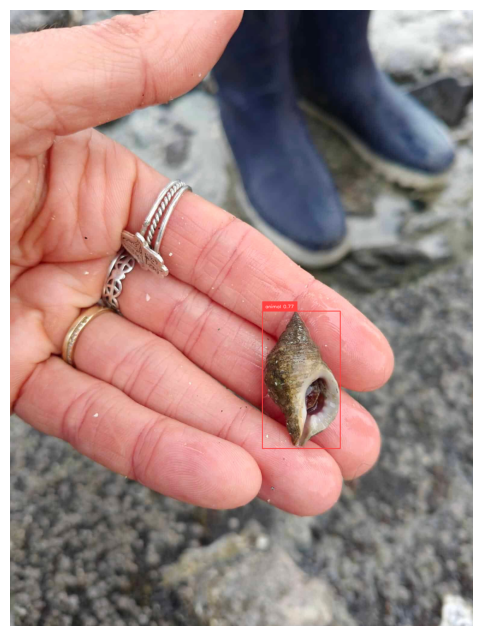

In [10]:
plot(
    image=cv2.imread(f"{IMG_PATH}/110297_Pourpre_petite_pierre_2088.jpg"),
    classes=base_model.ontology.classes(),
    detections=results
)

## Distillation et entraînement de YOLOv8 large

In [11]:
base_model.label(
    input_folder=f"{IMG_PATH}",
    output_folder=f"{DATA_PATH}/labeled-images"
)

Labeling ../dataset_biolit/images/110410_Vélelle_2090.jpg: 100%|██████████| 1599/1599 [24:52<00:00,  1.07it/s]                                    


Labeled dataset created - ready for distillation.


In [12]:
os.listdir(f"{DATA_PATH}/labeled-images/")

['images', 'annotations', 'data.yaml', 'train', 'valid']

In [5]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [6]:
_original_load = torch.load
torch.load = lambda *args, **kwargs: _original_load(*args, **kwargs, weights_only=False)

target_model = YOLOv8("yolov8l.pt")

In [7]:
# target_model = YOLOv8("yolov8n.pt")
target_model = YOLOv8("yolov8l.pt")

In [8]:
import numpy as np 
np.__version__

'1.26.4'

In [9]:
target_model.train(
    f"{DATA_PATH}/labeled-images/data.yaml", 
    epochs=100,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.22 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.81 🚀 Python-3.12.9 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
yolo/engine/trainer: task=detect, mode=train, model=yolov8l.pt, data=../dataset_biolit/labeled-images/data.yaml, epochs=100, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False, classes

## Résultats

In [10]:
from IPython.display import Image

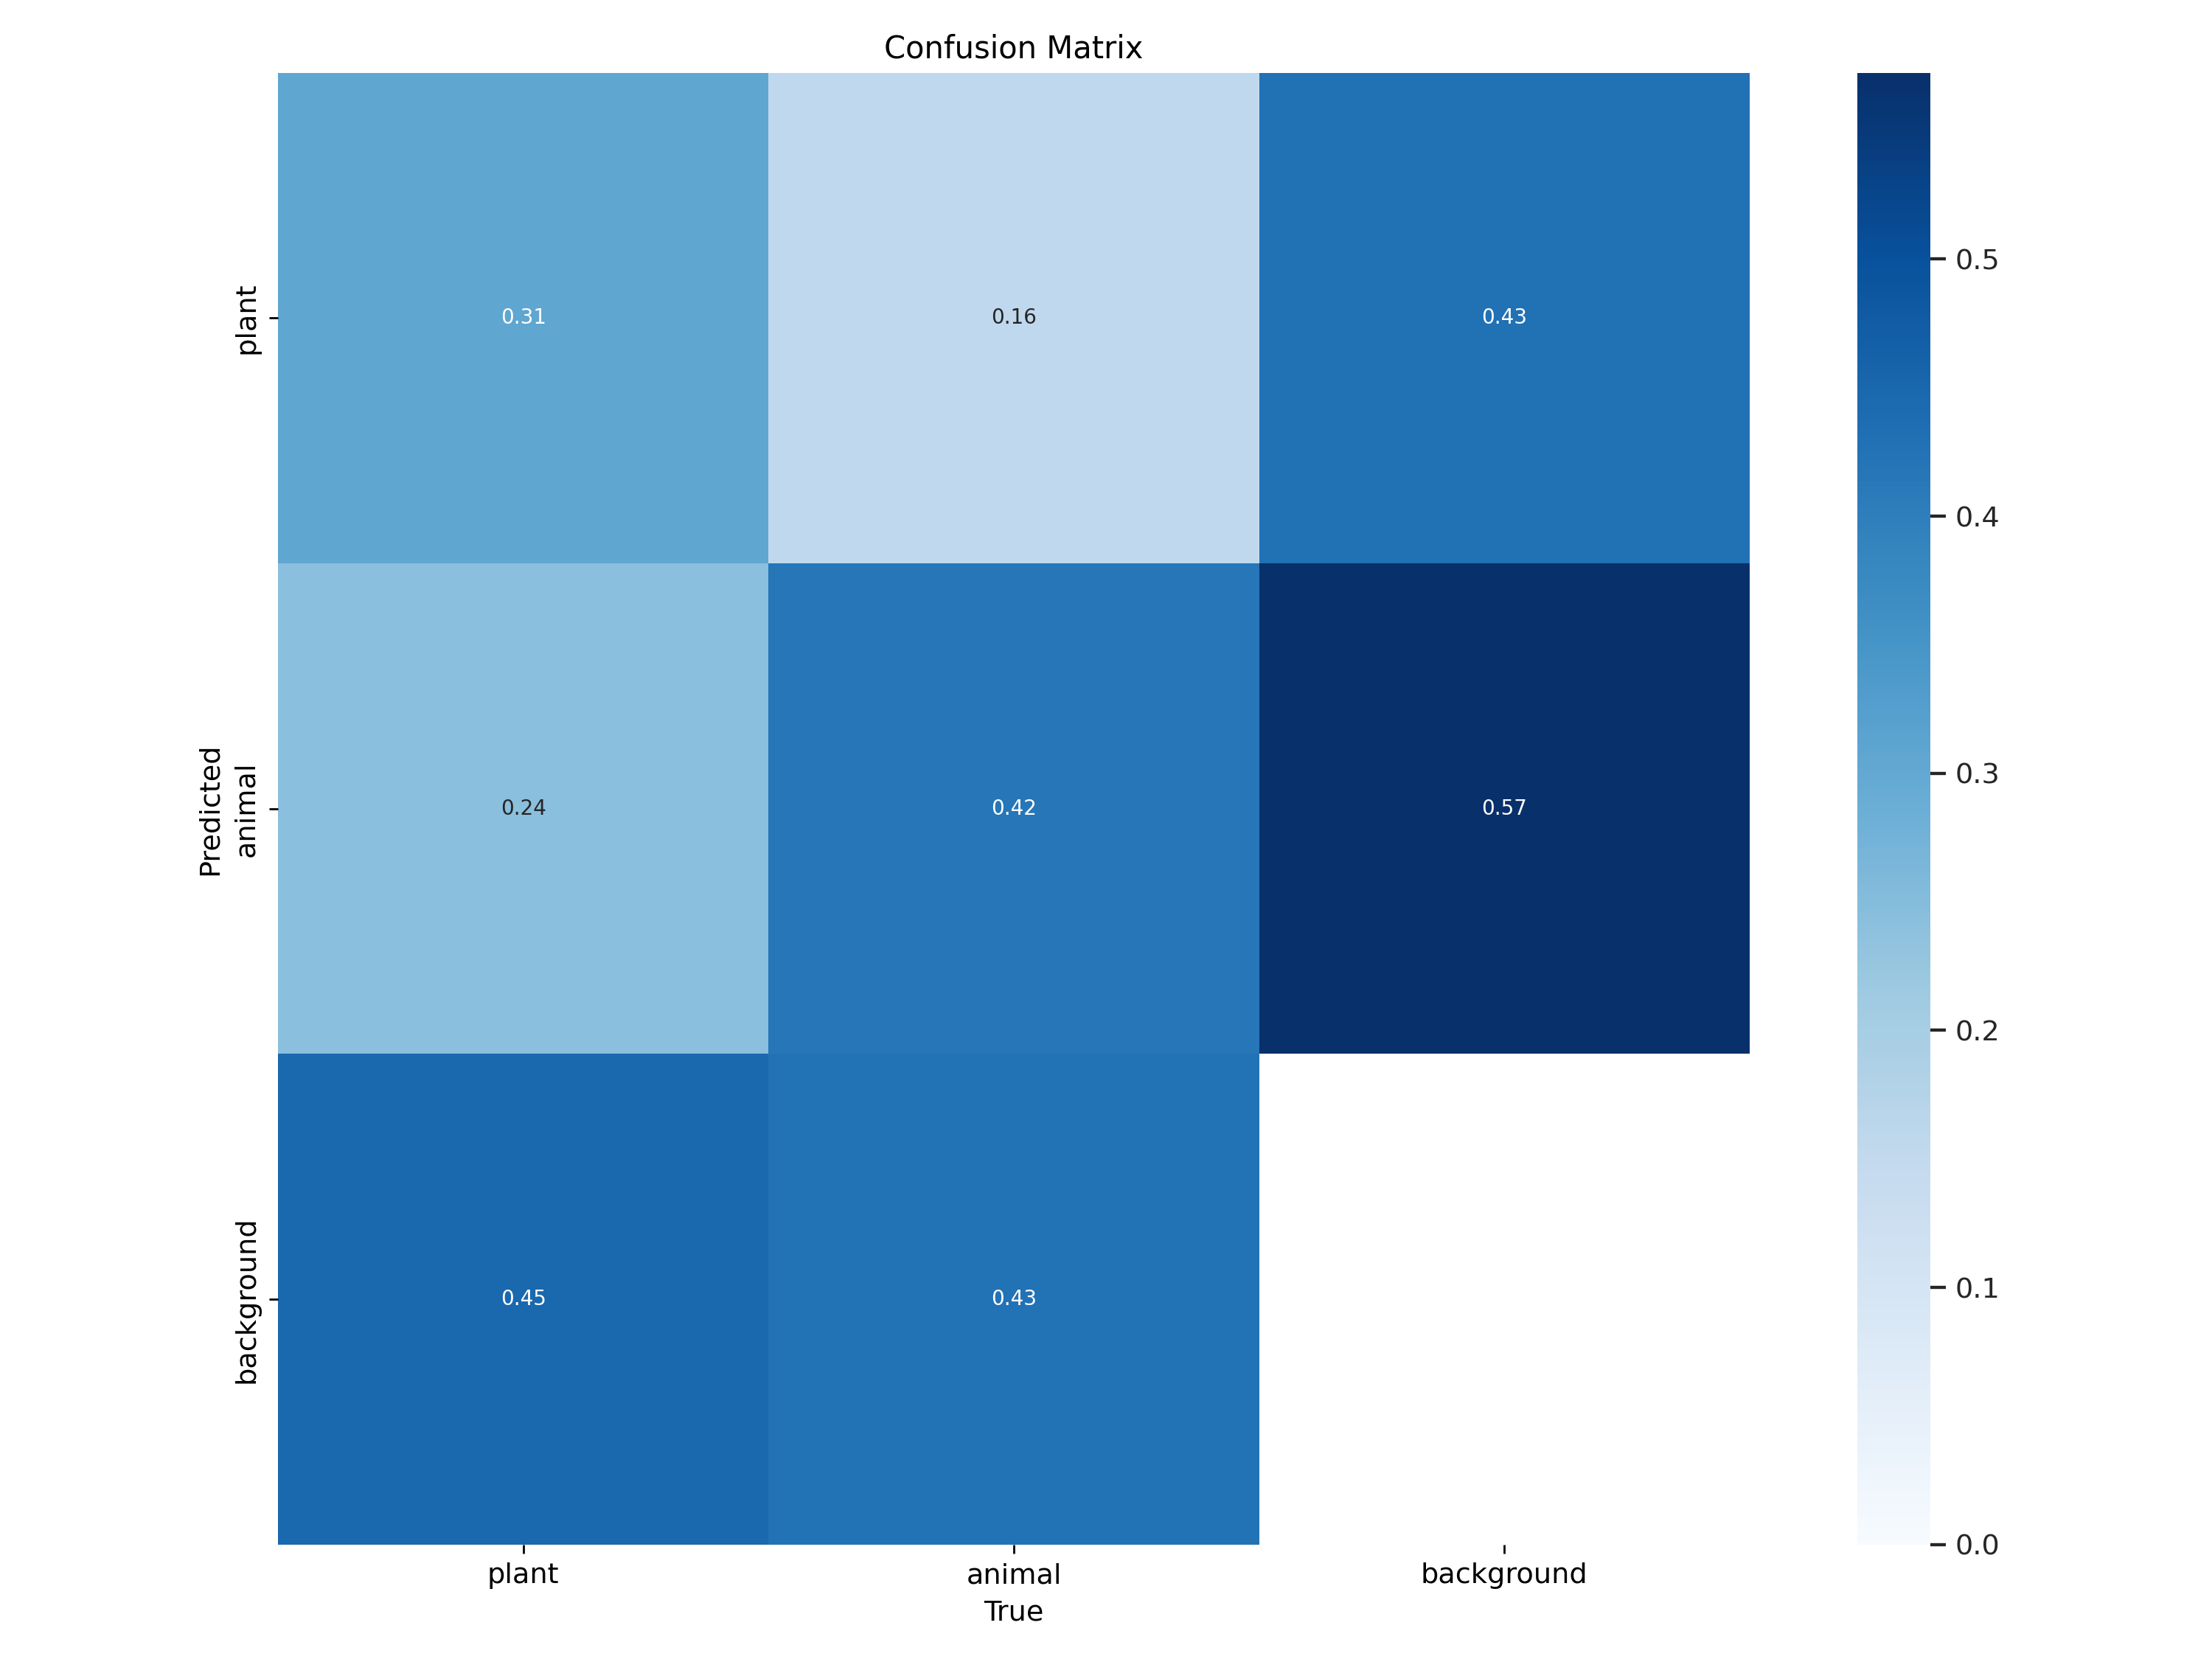

In [13]:
Image(filename="../runs/detect/train/confusion_matrix.png", width=600)

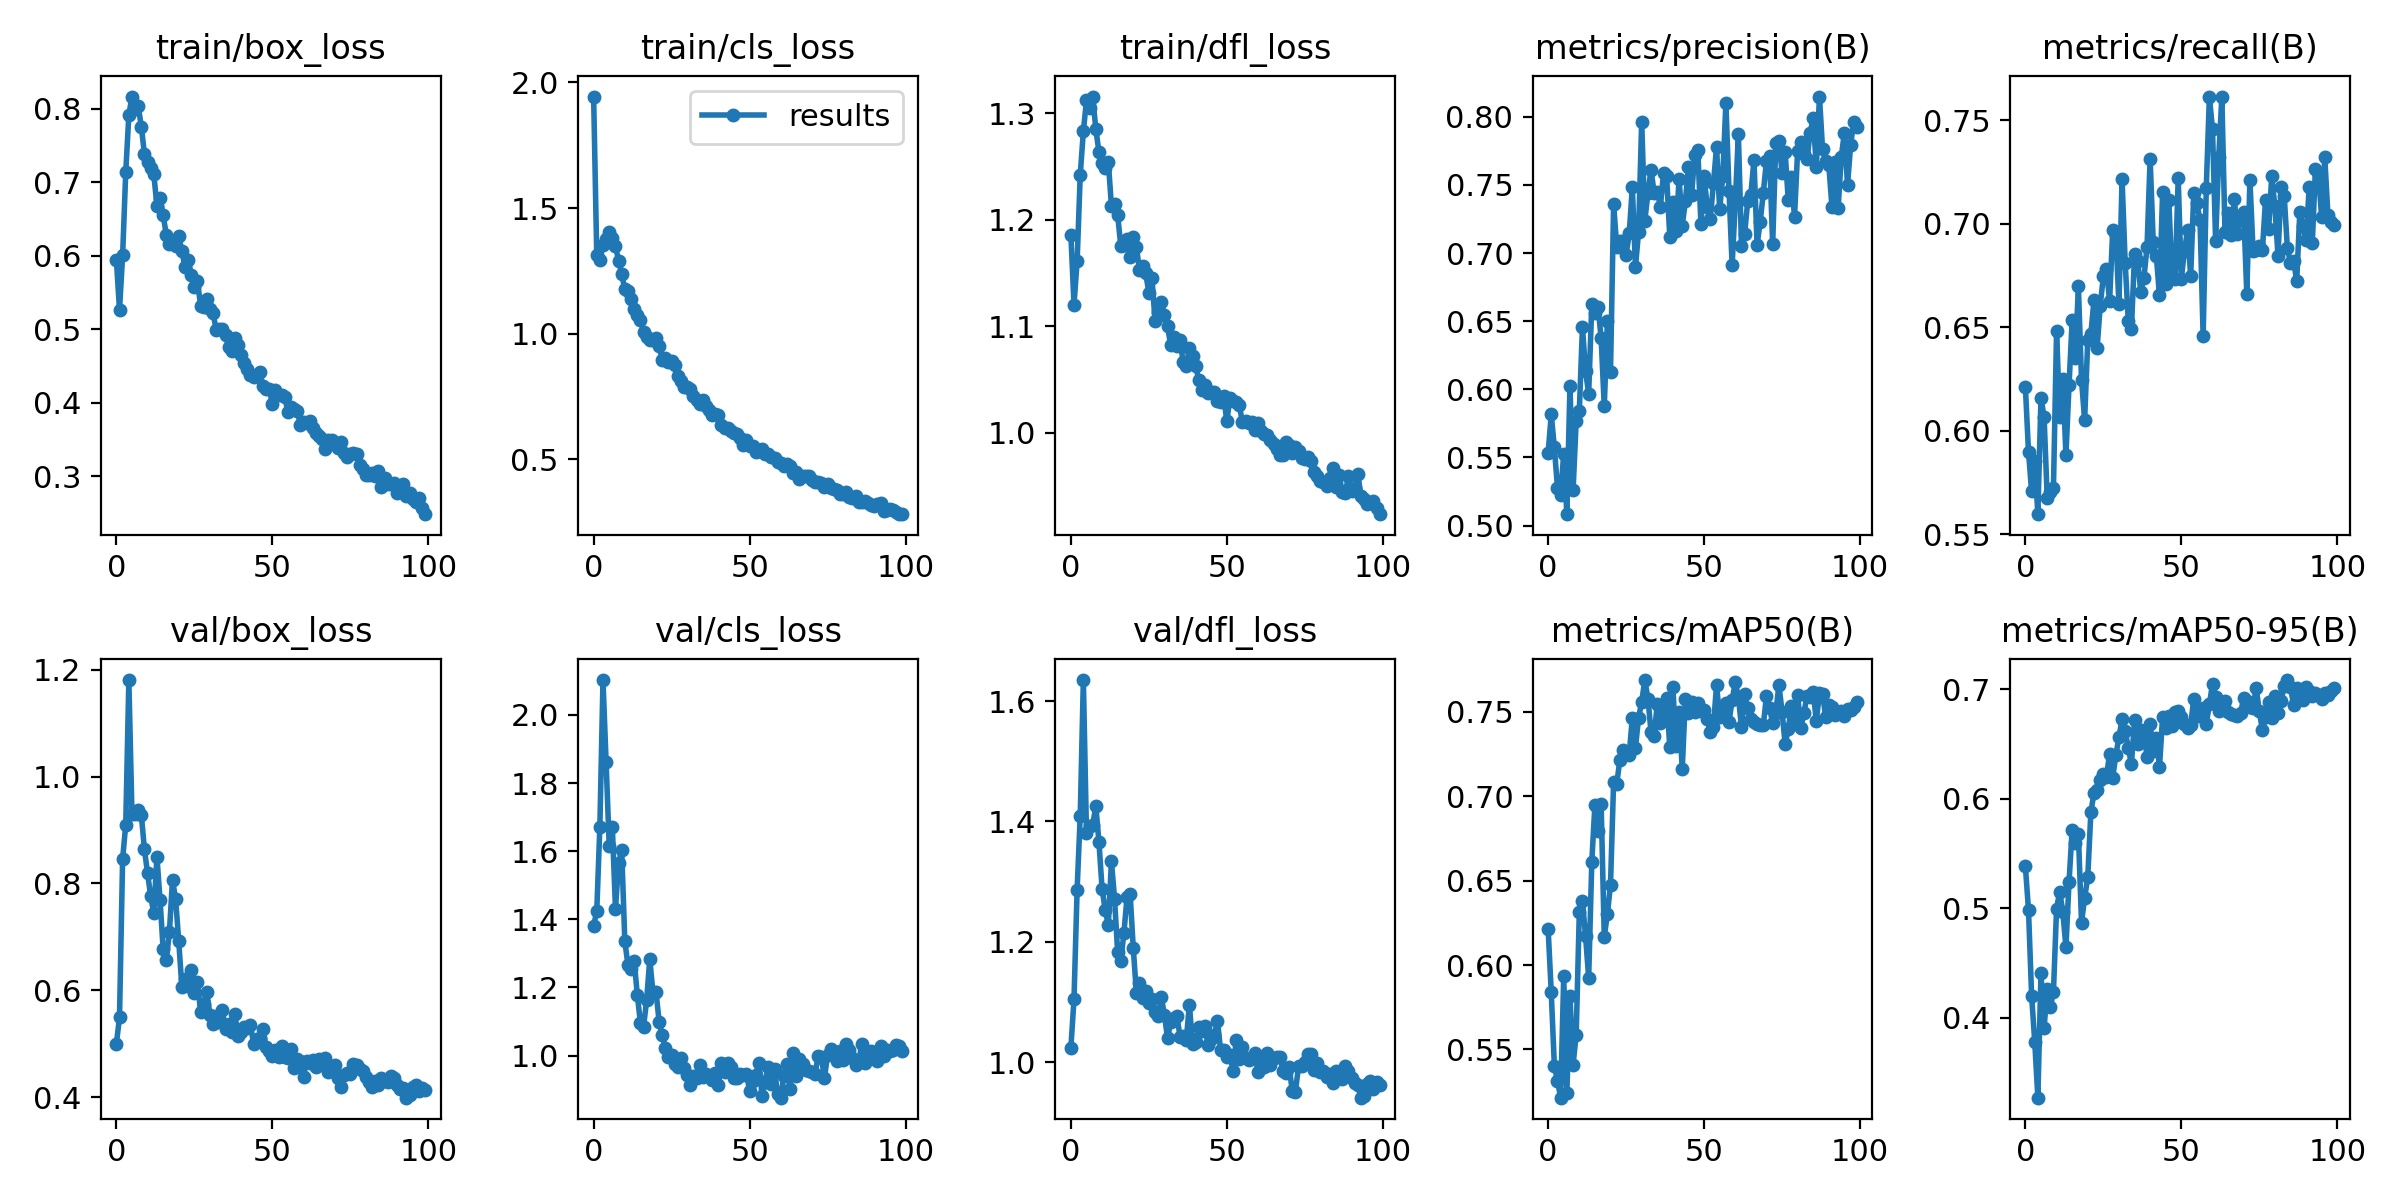

In [14]:
Image(filename=f"../runs/detect/train/results.png", width=600)

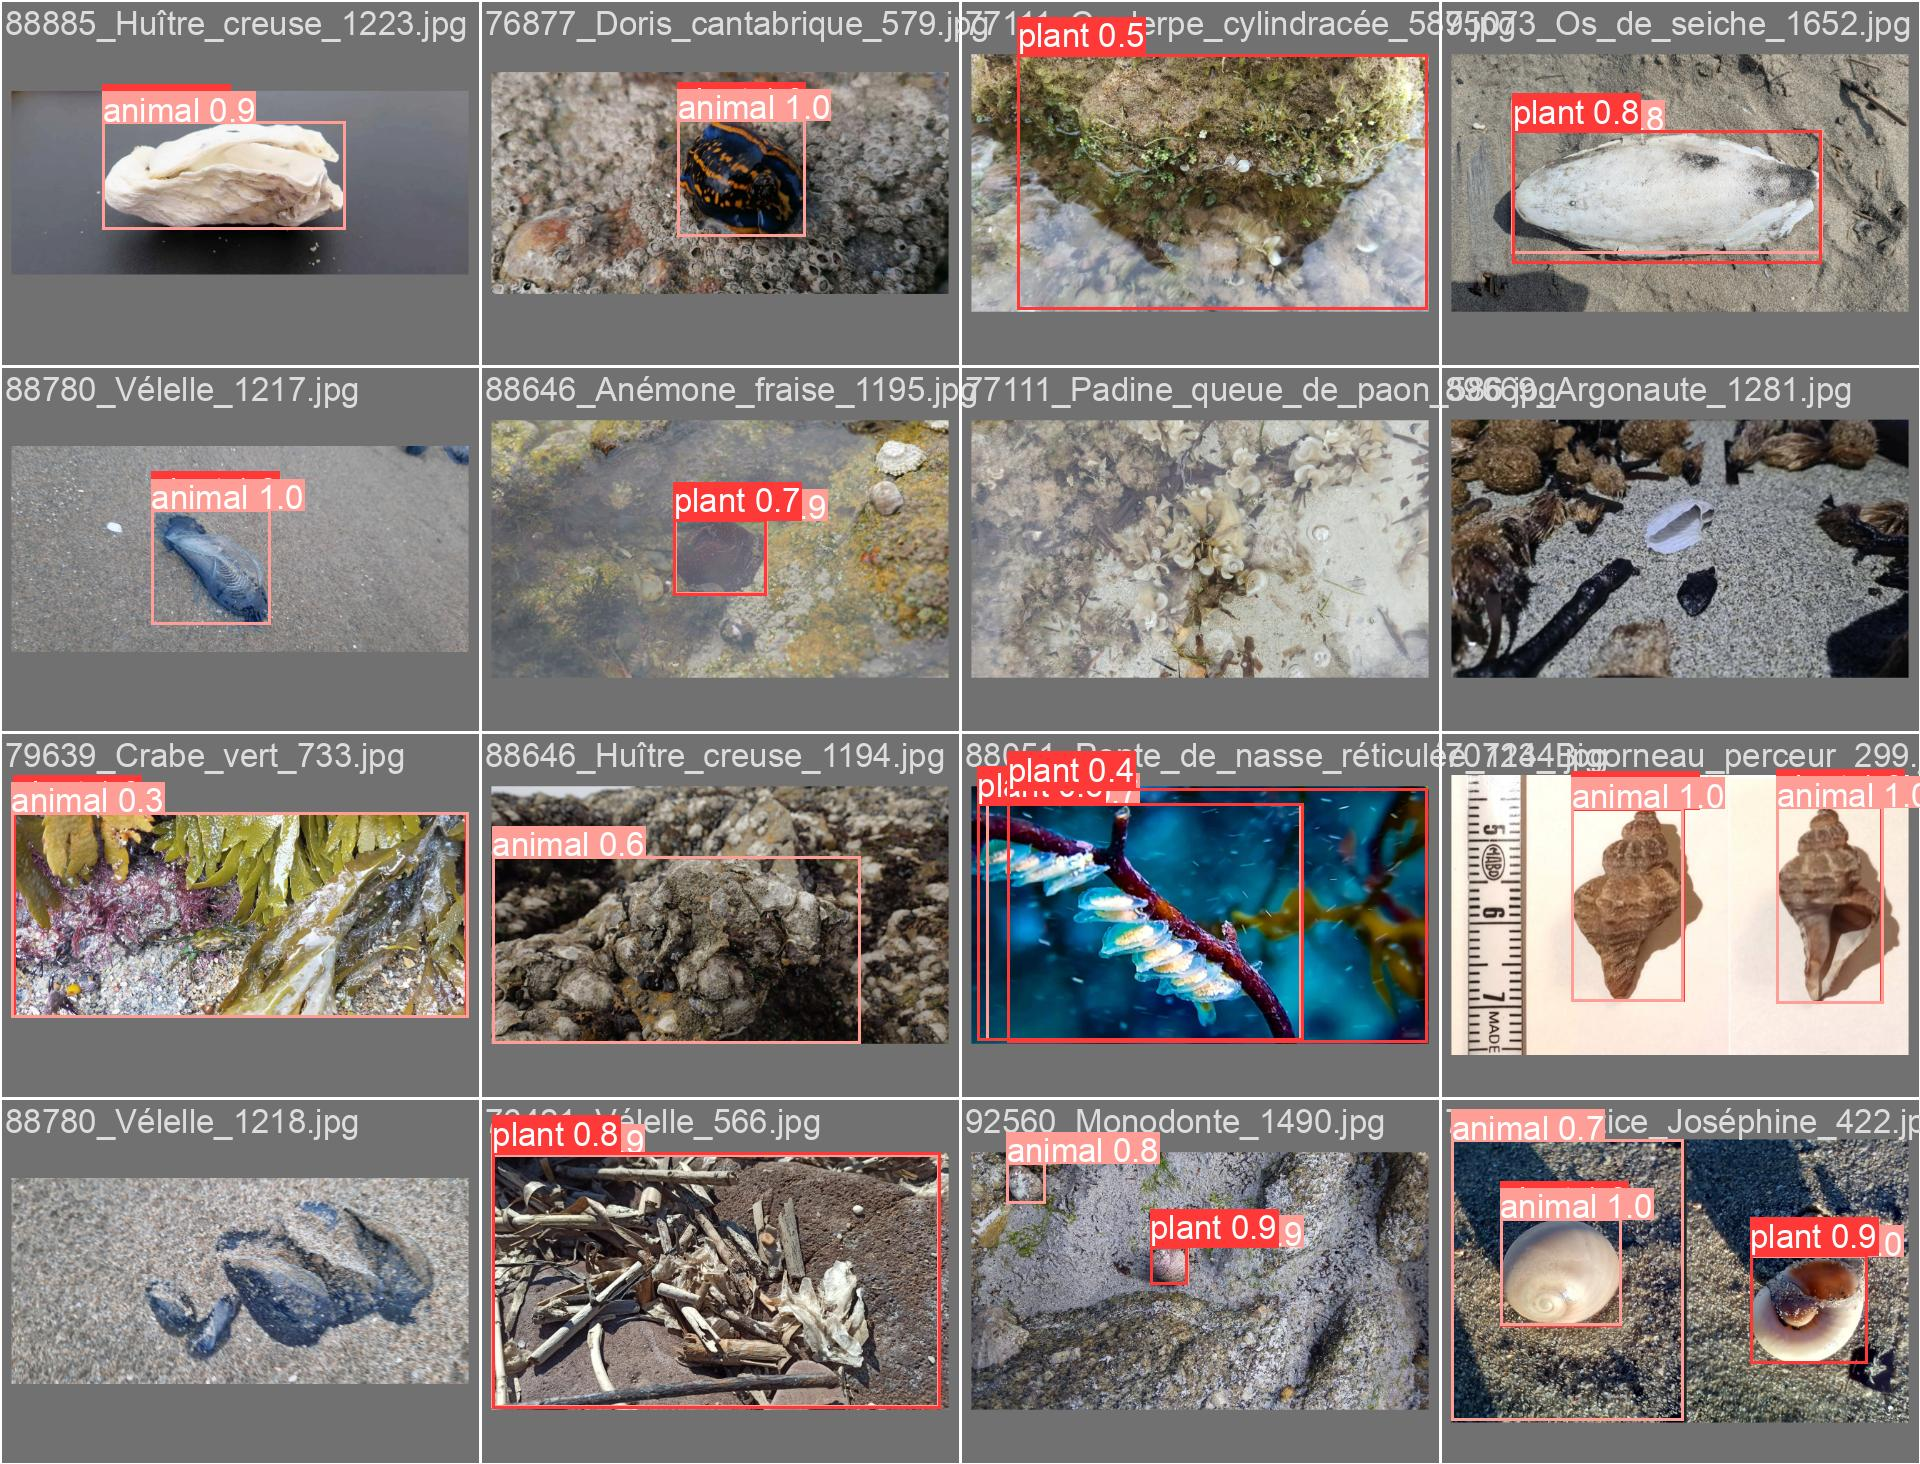

In [15]:
Image(filename=f'../runs/detect/train/val_batch0_pred.jpg', width=600)